In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\matches_full.csv")
pd.set_option('display.max_columns', None)

In [3]:
data.sample(5)

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,captain,formation,opp formation,referee,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
2094,24,2022-01-02,21:00,La Liga,Matchweek 19,Sun,Away,W,1.0,0.0,Mallorca,1.3,0.8,64.0,14654.0,Gerard Piqué,4-3-3,4-2-3-1,Antonio Matéu Lahoz,Match Report,NaN,13.0,3.0,16.1,1.0,0,0,2022,Barcelona
2485,36,2022-04-11,21:00,La Liga,Matchweek 31,Mon,Home,D,1.0,1.0,Valencia,0.6,0.5,55.0,9302.0,Óscar Trejo,4-2-3-1,4-1-4-1,Ricardo de Burgos,Match Report,NaN,11.0,4.0,19.7,1.0,0,0,2022,Rayo Vallecano
3088,26,2021-02-28,14:00,La Liga,Matchweek 25,Sun,Home,D,1.0,1.0,Valladolid,0.9,0.7,65.0,NaN,Hugo Mallo,4-1-3-2,4-4-2,David Medié,Match Report,NaN,11.0,2.0,17.0,1.0,0,0,2021,Celta Vigo
313,2,2024-08-29,19:00,La Liga,Matchweek 3,Thu,Home,W,4.0,0.0,Osasuna,2.4,0.0,60.0,13275.0,Iván Martín,4-4-2,4-2-3-1,Francisco Hernández,Match Report,NaN,10.0,5.0,14.3,0.0,0,0,2025,Girona
2978,39,2021-04-07,21:00,La Liga,Matchweek 29,Wed,Home,D,1.0,1.0,Athletic Club,0.9,0.7,51.0,NaN,Mikel Oyarzabal,4-4-2,4-4-2,José Sánchez,Match Report,NaN,12.0,2.0,17.2,0.0,0,0,2021,Real Sociedad


### Data PreProcessing

#### Data Cleaning

In [4]:
data = data.drop(['Unnamed: 0'], axis=1)
data = data.drop(['comp'], axis=1)
data = data.drop(['captain'], axis=1)
data = data.drop(['referee'], axis=1)
data = data.drop(['match report'], axis=1)
data = data.drop(['notes'], axis=1)

In [5]:
# Standarized Value in 'formation' column
data['formation'].unique()

array(['4-2-3-1', '4-3-3', '4-1-4-1', '3-4-3', '5-3-2', '4-4-2', '5-4-1',
       '4-1-2-1-2◆', '4-4-1-1', '4-2-2-2', '4-5-1', '3-5-2', '3-5-1-1',
       '3-1-4-2', '3-4-3◆', '3-4-1-2', '4-1-3-2', '4-3-1-2', '3-2-4-1',
       '4-3-2-1', '4-2-4-0', '3-3-3-1'], dtype=object)

In [6]:
# Membersihkan simbol tidak diperlukan, misalnya ◆
data['formation'] = data['formation'].str.replace('◆', '', regex=False)

In [7]:
data['formation'] = data['formation'].replace('4-2-4-0', '4-2-4')

In [8]:
data['date'] = pd.to_datetime(data['date'])

In [9]:
data['time'] = pd.to_datetime(data['time'], format = '%H:%M').dt.time

In [10]:
data['opponent'] = data['opponent'].astype('category')

In [11]:
# change the data type to int
data['sh'] = data['sh'].astype(int)
data['sot'] = data['sot'].astype(int)
data['ga'] = data['ga'].astype(int)
data['gf'] = data['gf'].astype(int)
data['fk'] = data['fk'].astype(int)

In [12]:
data.sample(5)

,date,time,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,formation,opp formation,sh,sot,dist,fk,pk,pkatt,season,team
2185,2022-04-29,21:00:00,Matchweek 34,Fri,Home,D,1,1,Cádiz,0.7,0.9,58.0,37113.0,4-2-3-1,4-2-3-1,11,6,20.2,0,0,0,2022,Sevilla
3758,2019-10-30,19:00:00,Matchweek 11,Wed,Home,L,1,2,Levante,1.6,1.8,65.0,28142.0,4-1-4-1,4-4-2,17,5,14.7,0,0,0,2020,Real Sociedad
520,2023-08-25,21:30:00,Matchweek 3,Fri,Away,W,1,0,Celta Vigo,1.4,1.2,63.0,23057.0,4-1-2-1-2,5-3-2,9,2,19.4,0,0,1,2024,Real Madrid
4261,2020-01-19,12:00:00,Matchweek 20,Sun,Home,W,4,1,Valencia,1.9,0.4,43.0,9856.0,4-4-2,4-4-2,14,6,16.7,1,0,0,2020,Mallorca
3279,2021-03-05,21:00:00,Matchweek 26,Fri,Home,W,2,1,Villarreal,1.9,1.9,53.0,NaN,4-4-2,4-4-2,24,3,19.6,1,1,1,2021,Valencia


#### Check NaN Value & Handling Missing Value

In [13]:
data.isnull().sum()

date               0
time               0
round              0
day                0
venue              0
result             0
gf                 0
ga                 0
opponent           0
xg                 0
xga                0
poss               0
attendance       974
formation          0
opp formation      0
sh                 0
sot                0
dist               3
fk                 0
pk                 0
pkatt              0
season             0
team               0
dtype: int64

In [14]:
data['attendance'] = data.groupby(['team', 'venue', 'opponent'])['attendance'].transform(
    lambda x: x.fillna(x.median())
)

C:\Users\ryana\AppData\Local\Temp\ipykernel_12596\321960465.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data['attendance'] = data.groupby(['team', 'venue', 'opponent'])['attendance'].transform(
C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keep

In [15]:
# we still got the null value, then we will imputation with median techic
data['attendance'] = data['attendance'].fillna(data['attendance'].median())

In [16]:
# change the data type to int
data['attendance'] = data['attendance'].astype(int)

In [17]:
data['dist'] = data.groupby(['venue', 'team'])['dist'].transform(
    lambda x: x.fillna(x.mean())
)

In [18]:
data.isnull().sum()

date             0
time             0
round            0
day              0
venue            0
result           0
gf               0
ga               0
opponent         0
xg               0
xga              0
poss             0
attendance       0
formation        0
opp formation    0
sh               0
sot              0
dist             0
fk               0
pk               0
pkatt            0
season           0
team             0
dtype: int64

### Machine Learning

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
data_model = data.copy()

In [ ]:
data_model = data_model.drop('time', axis=1)

In [ ]:
data_model.sample(3)

#### Feature Engginering

In [21]:
result_map = {'W':2, 'D':1, 'L':0}
data_model['target_pred'] = data_model['result'].map(result_map)

In [22]:
# Poin dari result
result_map_point = {'W': 3, 'D': 1, 'L': 0}
data_model['points'] = data_model['result'].map(result_map_point)

In [23]:
data_model.sample()

,date,time,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,formation,opp formation,sh,sot,dist,fk,pk,pkatt,season,team,target_pred,points
1966,2022-09-10,16:15:00,Matchweek 5,Sat,Home,L,2,3,Sevilla,2.5,2.0,58.0,20135,4-2-3-1,4-2-3-1,18,4,18.7,0,1,1,2023,Espanyol,0,0


In [24]:
#Checking Value == 0
def check_zero(data, kolom_list):
    value={}
    for kolom in kolom_list:
        jumlah_nol = (data[kolom] == 0).sum()
        value[kolom] = jumlah_nol
    return value

In [25]:
critical_cols = ['poss', 'xga', 'xg', 'sh', 'pkatt']
hasil_cek = check_zero(data_model, critical_cols)

for kolom, jumlah in hasil_cek.items():
    print(f"Count Value '0' in column '{kolom}': {jumlah}")

Count Value '0' in column 'poss': 0
Count Value '0' in column 'xga': 10
Count Value '0' in column 'xg': 10
Count Value '0' in column 'sh': 3
Count Value '0' in column 'pkatt': 3656


In [26]:
#create feature that indicate attacking power vs defensive power
data_model['xg_diff'] = data_model['xg'] - data_model['xga']

In [27]:
# shooting Accuracy
data_model['sh_accuracy'] = data_model.apply(
    lambda row: row['sot'] / row['sh'] if row['sh'] != 0 else 0,
    axis=1
)

In [28]:
data_model['conversion_rate'] = data_model.apply(
    lambda row: row['gf'] / row['sh'] if row['sh'] != 0 else 0,
    axis=1
)

In [29]:
data_model['PCR'] = data_model.apply(
    lambda row: row['pk'] / row['pkatt'] if row['pkatt'] != 0 else 0,
    axis=1
)

In [30]:
data_model['finishing_efficiency'] = data_model.apply(
    lambda row: row['gf'] / row['xg'] if row['xg'] != 0 else 0,
    axis=1
)

In [31]:
data_model['sh_per_poss'] = data_model.apply(
    lambda row: row['sh'] / row['poss'] if row['poss'] != 0 else 0,
    axis=1
)

In [32]:
data_model['sot_per_xg'] = data_model.apply(
    lambda row: row['sot'] / row['xg'] if row['xg'] != 0 else 0,
    axis=1
)

In [33]:
data_model['fk_per_sh'] = data_model.apply(
    lambda row: row['fk'] / row['sh'] if row['sh'] != 0 else 0,
    axis=1
)

In [ ]:


# Buat rata-rata poin 5 pertandingan sebelumnya
data_model['avg_pts_last5'] = data_model.groupby('team')['points'].shift(1).rolling(5).mean()

# Buat rata-rata xG 5 pertandingan sebelumnya
data_model['avg_xg_last5'] = data_model.groupby('team')['xg'].shift(1).rolling(5).mean()

# Rata-rata possession 5 pertandingan sebelumnya
data_model['avg_poss_last5'] = data_model.groupby('team')['poss'].shift(1).rolling(5).mean()

In [ ]:
# Home/Away flag
data_model['is_home'] = data_model['venue'].map({'Home': 1, 'Away': 0})

# Urutkan agar rolling tidak keliru
data_model = data_model.sort_values(by=['team', 'date'])

# Rolling (lagging) features - 5 pertandingan sebelumnya
rolling_cols = ['points', 'xg', 'poss', 'gf', 'ga']
for col in rolling_cols:
    data_model[f'avg_{col}_last5'] = (
        data_model.groupby('team')[col]
        .shift(1)  # geser dulu agar tidak bocor
        .rolling(5)
        .mean()
    )

In [ ]:
# Step 1: Buat kolom kemenangan (1 jika 'W', 0 selain itu)
data_model['win_flag'] = data_model['result'].map(lambda x: 1 if x == 'W' else 0)

# Step 2: Hitung jumlah kemenangan dari 5 pertandingan terakhir
data_model['form_win_last5'] = (
    data_model
    .groupby('team')['win_flag']
    .shift(1)  # penting: geser 1 agar tidak bocor
    .rolling(5)
    .sum()
)

In [ ]:
data_model.sample(2)

In [ ]:
# Buat kolom tahun
data_model['year'] = data_model['date'].dt.year

In [ ]:
# Hapus baris yang belum punya data lagging (karena masih NaN)
data_model = data_model.dropna()

# Split
train_df = data_model[data_model['year'] < 2025]
test_df = data_model[data_model['year'] == 2025]

# Target
target = 'target_pred'

In [ ]:
feature_cols = [
    'is_home',
    'avg_points_last5',
    'avg_xg_last5',
    'avg_poss_last5',
    'avg_gf_last5',
    'avg_ga_last5',
    'form_win_last5',
]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

#### Feature Selection

In [ ]:
# {'W':2, 'D':1, 'L':0}
data_model['target_pred'].value_counts()

In [34]:
#Train/Test Split
from sklearn.model_selection import train_test_split

cols = [
    'poss', 'sh', 'sot','fk', 'pk',	'pkatt', 'sh_accuracy',	'conversion_rate',	
    'PCR', 'finishing_efficiency', 'sh_per_poss', 'sot_per_xg',	'fk_per_sh'
]

# cols = [
#     'is_home',
#     'avg_points_last5',
#     'avg_xg_last5',
#     'avg_poss_last5',
#     'avg_gf_last5',
#     'avg_ga_last5',
#     'form_win_last5',
# ]


X = data_model[cols]
y = data_model['target_pred']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    shuffle=True,
                                                    stratify=y,
                                                    random_state=42
                                                    )

In [35]:
print(X_train.shape)
print(X_test.shape)

(3022, 13)
(1296, 13)


##### Baseline Model: Gradient Boosting Classifier with ALL Feature

In [36]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [37]:
#Initialize Classifier
gbc = GradientBoostingClassifier(max_depth=5, random_state=42)

#Train Classifier using ALl Feature
gbc.fit(X_train, y_train)

#make prediction
preds= gbc.predict(X_test)

# Evaluate model using f1-score
f1_score_all = round(f1_score(y_test, preds, average='weighted'),3)

print(f1_score_all)

0.555


In [ ]:
print(y_test.value_counts())

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import make_scorer, f1_score

# Buat scorer F1
f1 = make_scorer(f1_score, average='weighted')

# Inisialisasi model
model = GradientBoostingClassifier(max_depth=4, random_state=42)

# Cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring=f1)

# Tampilkan hasil
print("F1-score per fold:", scores)
print("Rata-rata F1-score:", scores.mean())

#### Variance threshold

In [38]:
X_train_v1, X_test_v1, y_tain_v1, y_test_v1 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [39]:
# Calculate the variance of each feature
X_train_v1.var(axis=0)

poss                    130.332096
sh                       23.185787
sot                       5.286747
fk                        0.477700
pk                        0.126520
pkatt                     0.165251
sh_accuracy               0.027730
conversion_rate           0.015113
PCR                       0.100243
finishing_efficiency      1.425941
sh_per_poss               0.008045
sot_per_xg                7.113731
fk_per_sh                 0.004584
dtype: float64

In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_X_train_v1 = scaler.fit_transform(X_train_v1)

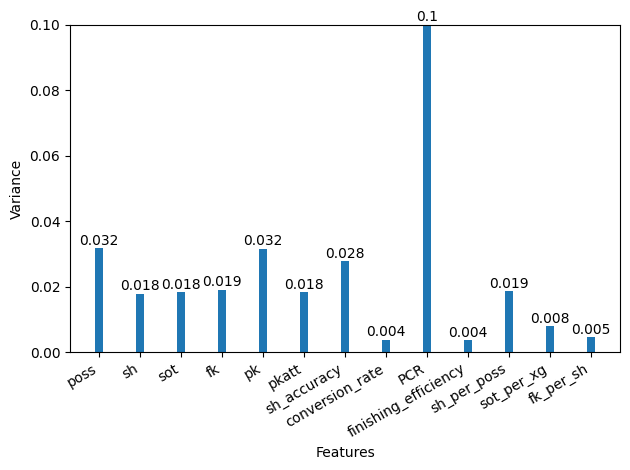

In [41]:
fig, ax = plt.subplots()

x = X.columns
y = scaled_X_train_v1.var(axis=0)

ax.bar(x, y, width=0.2)
ax.set_xlabel('Features')
ax.set_ylabel('Variance')
ax.set_ylim(0, 0.1)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.001, s=str(round(value, 3)), ha='center')
    
fig.autofmt_xdate()
plt.tight_layout()

In [42]:
sel_X_train_v1 = X_train_v1.drop(['conversion_rate', 'finishing_efficiency', 'sot_per_xg', 'fk_per_sh', 'PCR'], axis=1)
sel_X_test_v1 = X_test_v1.drop(['conversion_rate', 'finishing_efficiency', 'sot_per_xg', 'fk_per_sh', 'PCR'], axis=1)

gbc.fit(sel_X_train_v1, y_train)

var_preds = gbc.predict(sel_X_test_v1)

f1_score_var = round(f1_score(y_test_v1, var_preds, average='weighted'), 3)

print(f1_score_var)

0.44


In [48]:
df = data_model.copy()
df = df.sort_values(by=['team', 'date'])

In [49]:
import pandas as pd

def generate_team_form_features(df, window=5):
    """
    Buat fitur pre-match berdasarkan n pertandingan terakhir tim (default: 5).
    Asumsikan dataframe sudah terurut berdasarkan tanggal.

    Params:
    - df: DataFrame yang berisi kolom seperti ['team', 'date', 'xg', 'xga', 'poss', 'sot', 'gf', 'ga', 'points']
    - window: Jumlah pertandingan terakhir yang ingin dihitung rata-ratanya

    Returns:
    - df_final: DataFrame dengan fitur baru per tim per match
    """
    

    # Buat list fitur rolling yang ingin dihitung
    rolling_features = {
        'xg': 'avg_xg_last_5',
        'xga': 'avg_xga_last_5',
        'poss': 'avg_poss_last_5',
        'sot': 'avg_sot_last_5',
        'gf': 'goals_scored_last_5',
        'ga': 'goals_conceded_last_5',
        'points': 'form_points_last_5'
    }

    for col, new_name in rolling_features.items():
        df[new_name] = (
            df.groupby('team')[col]
              .shift(1)  # geser ke belakang agar tidak termasuk match saat ini
              .rolling(window=window, min_periods=1)
              .mean()
              .reset_index(level=0, drop=True)
        )

    # Hitung win rate dari 5 pertandingan terakhir
    df['win_last'] = df['points'].apply(lambda x: 1 if x == 3 else 0)
    df['win_rate_last_5'] = (
        df.groupby('team')['win_last']
          .shift(1)
          .rolling(window=window, min_periods=1)
          .mean()
          .reset_index(level=0, drop=True)
    )

    # Hapus kolom bantu
    df = df.drop(columns=['win_last'])

    return df


In [46]:
# Pastikan kolom 'points' sudah ada
result_map_point = {'W': 3, 'D': 1, 'L': 0}
df['points'] = df['result'].map(result_map_point)



NameError: name 'df' is not defined

In [52]:
df.sample(3)

,date,time,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,formation,opp formation,sh,sot,dist,fk,pk,pkatt,season,team,target_pred,points,xg_diff,sh_accuracy,conversion_rate,PCR,finishing_efficiency,sh_per_poss,sot_per_xg,fk_per_sh,avg_xg_last_5,avg_xga_last_5,avg_poss_last_5,avg_sot_last_5,goals_scored_last_5,goals_conceded_last_5,form_points_last_5,win_last,win_rate_last_5
1231,2024-03-30,16:15:00,Matchweek 30,Sat,Home,L,0,3,Osasuna,0.8,1.0,51.0,10565,4-3-3,4-4-2,12,5,19.8,1,0,0,2024,Almeria,0,0,-0.2,0.416667,0.000000,0.0,0.0,0.235294,6.25,0.083333,0.80,1.28,41.0,4.0,1.2,1.4,0.6,0,0.2
2482,2022-03-13,14:00:00,Matchweek 28,Sun,Home,D,1,1,Sevilla,0.4,0.3,44.0,9073,4-2-3-1,4-2-3-1,10,2,18.8,0,0,0,2022,Rayo Vallecano,1,1,0.1,0.200000,0.100000,0.0,2.5,0.227273,5.00,0.000000,0.98,0.90,44.0,3.2,0.8,0.6,1.6,0,0.4
929,2024-04-20,16:15:00,Matchweek 32,Sat,Away,L,1,2,Rayo Vallecano,0.5,0.5,36.0,12617,4-3-3,4-4-2,6,2,20.8,0,0,0,2024,Osasuna,0,0,0.0,0.333333,0.166667,0.0,2.0,0.166667,4.00,0.000000,1.04,1.60,36.0,1.4,0.6,1.4,1.0,0,0.2


In [51]:
# Jalankan fungsi
df_features = generate_team_form_features(df)

In [57]:
df[df['team'] == 'Barcelona'].head(3)

,date,time,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,formation,opp formation,sh,sot,dist,fk,pk,pkatt,season,team,target_pred,points,xg_diff,sh_accuracy,conversion_rate,PCR,finishing_efficiency,sh_per_poss,sot_per_xg,fk_per_sh,avg_xg_last_5,avg_xga_last_5,avg_poss_last_5,avg_sot_last_5,goals_scored_last_5,goals_conceded_last_5,form_points_last_5,win_last,win_rate_last_5
3596,2019-08-16,21:00:00,Matchweek 1,Fri,Away,L,0,1,Athletic Club,0.9,0.5,71.0,47693,4-3-3,4-2-3-1,11,2,13.3,0,0,0,2020,Barcelona,0,0,0.4,0.181818,0.00,0.0,0.000000,0.154930,2.222222,0.0,0.84,0.88,57.2,4.2,1.2,0.8,1.8,0,0.6
3597,2019-08-25,21:00:00,Matchweek 2,Sun,Home,W,5,2,Betis,2.6,0.2,70.0,79159,4-3-3,4-4-2,20,7,15.6,0,0,0,2020,Barcelona,2,3,2.4,0.350000,0.25,0.0,1.923077,0.285714,2.692308,0.0,0.90,0.96,59.2,4.0,1.0,1.0,1.4,1,0.4
3598,2019-08-31,17:00:00,Matchweek 3,Sat,Away,D,2,2,Osasuna,0.4,1.8,73.0,16742,4-3-3,4-4-2,8,4,20.6,0,0,0,2020,Barcelona,1,1,-1.4,0.500000,0.25,0.0,5.000000,0.109589,10.000000,0.0,1.26,0.80,61.6,4.4,1.2,0.6,2.0,0,0.6


In [58]:
# Misalnya target kita adalah 'target_pred' (menang, seri, kalah)
X = df[['xg_diff', 'sh_accuracy', 'conversion_rate', 'PCR', 'finishing_efficiency', 
        'sh_per_poss', 'sot_per_xg', 'fk_per_sh', 'avg_xg_last_5', 'avg_xga_last_5', 
        'avg_poss_last_5', 'avg_sot_last_5', 'goals_scored_last_5', 'goals_conceded_last_5', 
        'form_points_last_5', 'win_last', 'win_rate_last_5']]

y = df['target_pred']  # target kita adalah hasil pertandingan: 0 = kalah, 1 = seri, 2 = menang

# Split data menjadi training dan testing set (80% latih, 20% uji)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.impute import SimpleImputer

# Inisialisasi imputer untuk mengganti NaN dengan rata-rata (mean)
imputer = SimpleImputer(strategy='mean')

# Terapkan imputasi ke X_train dan X_test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Cek apakah ada NaN yang tersisa
import numpy as np
print(np.any(np.isnan(X_train_imputed)))  # False jika tidak ada NaN

False


In [63]:
# Hapus baris yang mengandung NaN
X_train = X_train.dropna()
y_train = y_train[X_train.index]  # pastikan y_train tetap sesuai dengan X_train

X_test = X_test.dropna()
y_test = y_test[X_test.index]

In [64]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# Inisialisasi model
model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Latih model dengan data latih
model.fit(X_train, y_train)

# Prediksi dengan data ujiy_pred = model.predict(X_test)

# Evaluasi kinerja model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Laporan klasifikasi (precision, recall, f1-score per kelas)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

NameError: name 'y_pred' is not defined